In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 2: Load and preprocess dataset
df = pd.read_csv("labelled_merged_dataset.csv")

title_counts = df['Title'].value_counts()
df['IsChain'] = df['Title'].apply(lambda x: 1 if title_counts[x] > 1 else 0)

def parse_categories(x):
    try:
        return len(ast.literal_eval(x)) if pd.notnull(x) else 0
    except:
        return 0
df['tag_count'] = df['Categories'].apply(parse_categories)
df['RatingBinary'] = df['Rating'].map({'Good': 1, 'Bad': 0})

df.head()

,Title,Category,Rating,Address,Categories,ZCTA,NAME,Median_Income,Population,Males_20yrs_age,...,Males_60yrs_age,Females_20yrs_age,Females_30yrs_age,Females_60yrs_age,Asian,American,Hispanic_or_Latino,IsChain,tag_count,RatingBinary
0,Dairy Queen Grill & Chill,Fast food restaurant,Bad,"Dairy Queen Grill & Chill, 3143 US-280, Alexan...","['Fast food restaurant', 'Ice cream shop']",35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,2,0
1,Jake's Restaurant,American restaurant,Good,"Jake's Restaurant, 16 Broad St, Alexander City...",['American restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,1,1
2,Carib Kitchen,Caribbean restaurant,Good,"Carib Kitchen, 68 Broad St, Alexander City, AL...",['Caribbean restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,0,1,1
3,Cazadores Mexican Restaurant,Mexican restaurant,Good,"Cazadores Mexican Restaurant, 910 Cherokee Rd,...",['Mexican restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,1,1
4,La Posada Mexican Grill,Mexican restaurant,Bad,"La Posada Mexican Grill, 3714 US-280, Alexande...","['Mexican restaurant', 'Latin American restaur...",35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,2,0


In [2]:
from sklearn.preprocessing import StandardScaler
# Step 3: Define features and label
features = ['Median_Income', 'Population', 'American', 'Asian', 'Hispanic_or_Latino', 'IsChain', 'tag_count']
X = df[features]
y = df['RatingBinary']

# Step 4: Standardize the features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-Test Split (stratified to preserve label ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

# Display samples
print("Cleaned Data Sample: \n")
print(df[features + ['RatingBinary']].head())

train_sample = pd.DataFrame(X_train, columns=features)
test_sample = pd.DataFrame(X_test, columns=features)

print("\n Training Set Sample (80%): \n")
train_sample['RatingBinary'] = y_train.values
print(train_sample.head())

print("\n Testing Set Sample (20%): \n")
test_sample['RatingBinary'] = y_test.values
print(test_sample.head())

Cleaned Data Sample: 

   Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
0          46730       20406      1864    107                 899        1          2             0
1          46730       20406      1864    107                 899        1          1             1
2          46730       20406      1864    107                 899        0          1             1
3          46730       20406      1864    107                 899        1          1             1
4          46730       20406      1864    107                 899        1          2             0

 Training Set Sample (80%): 

   Median_Income  Population  American     Asian  Hispanic_or_Latino   IsChain  tag_count  RatingBinary
0       0.180318   -1.413102 -0.583995 -0.442815           -0.559532 -0.724457  -0.885783             1
1       0.124473    2.562481 -0.156910  0.896870            1.990101  1.380344   0.017960             0
2      -0.570301   -1.496953 -0.89

Linear Kernel - C=0.01
Accuracy: 0.6551736840166501
              precision    recall  f1-score   support

           0       0.74      0.50      0.60     13795
           1       0.61      0.81      0.70     13352

    accuracy                           0.66     27147
   macro avg       0.67      0.66      0.65     27147
weighted avg       0.68      0.66      0.65     27147



<Figure size 600x400 with 0 Axes>

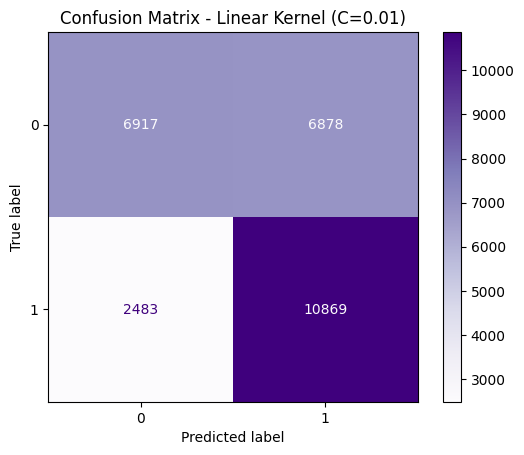

Linear Kernel - C=1
Accuracy: 0.6551736840166501
              precision    recall  f1-score   support

           0       0.74      0.50      0.60     13795
           1       0.61      0.81      0.70     13352

    accuracy                           0.66     27147
   macro avg       0.67      0.66      0.65     27147
weighted avg       0.68      0.66      0.65     27147



<Figure size 600x400 with 0 Axes>

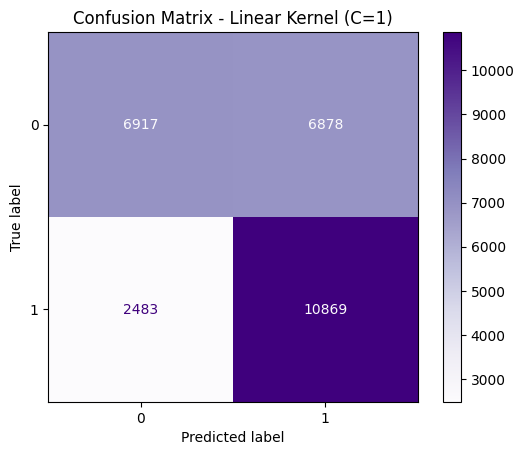

Linear Kernel - C=0.1
Accuracy: 0.6551736840166501
              precision    recall  f1-score   support

           0       0.74      0.50      0.60     13795
           1       0.61      0.81      0.70     13352

    accuracy                           0.66     27147
   macro avg       0.67      0.66      0.65     27147
weighted avg       0.68      0.66      0.65     27147



<Figure size 600x400 with 0 Axes>

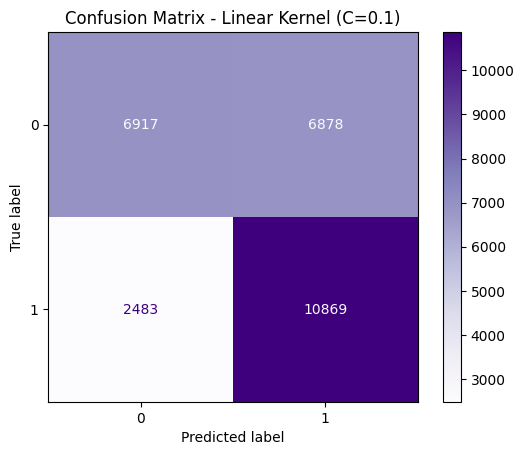

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Linear Kernel with C=0.01
svm_linear_c001 = SVC(kernel='linear', C=0.01)
svm_linear_c001.fit(X_train[:1000], y_train[:1000])
y_pred_linear_c001 = svm_linear_c001.predict(X_test)

print("Linear Kernel - C=0.01")
print("Accuracy:", accuracy_score(y_test, y_pred_linear_c001))
print(classification_report(y_test, y_pred_linear_c001))

cm_linear_c001 = confusion_matrix(y_test, y_pred_linear_c001)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear_c001, display_labels=svm_linear_c001.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Linear Kernel (C=0.01)")
plt.grid(False)
plt.show()

# Linear Kernel with C=1
svm_linear_c1 = SVC(kernel='linear', C=1)
svm_linear_c1.fit(X_train[:1000], y_train[:1000])
y_pred_linear_c1 = svm_linear_c1.predict(X_test)

print("Linear Kernel - C=1")
print("Accuracy:", accuracy_score(y_test, y_pred_linear_c1))
print(classification_report(y_test, y_pred_linear_c1))

cm_linear_c1 = confusion_matrix(y_test, y_pred_linear_c1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear_c1, display_labels=svm_linear_c1.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Linear Kernel (C=1)")
plt.grid(False)
plt.show()

# Linear Kernel with C=0.1
svm_linear_c01 = SVC(kernel='linear', C=0.1)
svm_linear_c01.fit(X_train[:1000], y_train[:1000])
y_pred_linear_c01 = svm_linear_c01.predict(X_test)

print("Linear Kernel - C=0.1")
print("Accuracy:", accuracy_score(y_test, y_pred_linear_c01))
print(classification_report(y_test, y_pred_linear_c01))

cm_linear_c01 = confusion_matrix(y_test, y_pred_linear_c01)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear_c01, display_labels=svm_linear_c01.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Linear Kernel (C=0.1)")
plt.grid(False)
plt.show()


RBF Kernel - C=0.01
Accuracy: 0.4918407190481453
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     13795
           1       0.49      1.00      0.66     13352

    accuracy                           0.49     27147
   macro avg       0.25      0.50      0.33     27147
weighted avg       0.24      0.49      0.32     27147



<Figure size 600x400 with 0 Axes>

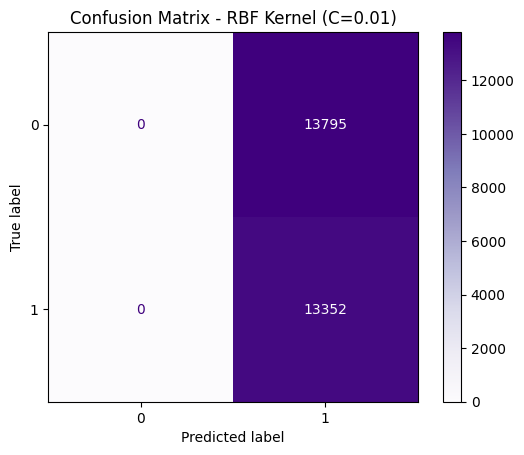

RBF Kernel - C=1
Accuracy: 0.6524477842855564
              precision    recall  f1-score   support

           0       0.71      0.54      0.61     13795
           1       0.62      0.77      0.69     13352

    accuracy                           0.65     27147
   macro avg       0.66      0.65      0.65     27147
weighted avg       0.66      0.65      0.65     27147



<Figure size 600x400 with 0 Axes>

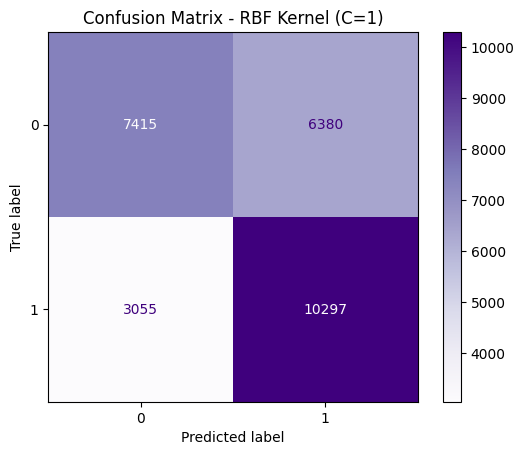

RBF Kernel - C=0.1
Accuracy: 0.6528161491140826
              precision    recall  f1-score   support

           0       0.70      0.56      0.62     13795
           1       0.62      0.75      0.68     13352

    accuracy                           0.65     27147
   macro avg       0.66      0.65      0.65     27147
weighted avg       0.66      0.65      0.65     27147



<Figure size 600x400 with 0 Axes>

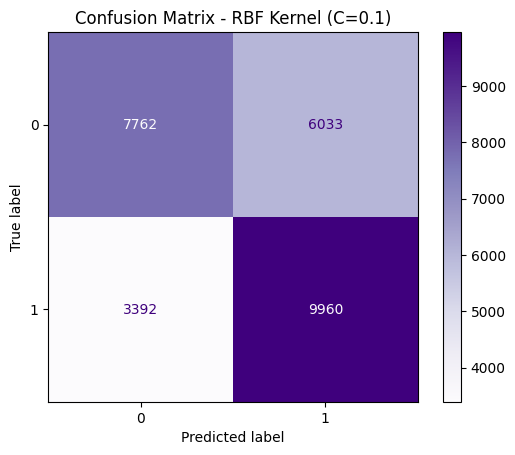

In [4]:
# RBF Kernel with C=0.01
svm_rbf_c001 = SVC(kernel='rbf', C=0.01)
svm_rbf_c001.fit(X_train[:1000], y_train[:1000])
y_pred_rbf_c001 = svm_rbf_c001.predict(X_test)

print("RBF Kernel - C=0.01")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf_c001))
print(classification_report(y_test, y_pred_rbf_c001, zero_division=0))

cm_rbf_c001 = confusion_matrix(y_test, y_pred_rbf_c001)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf_c001, display_labels=svm_rbf_c001.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - RBF Kernel (C=0.01)")
plt.grid(False)
plt.show()

# RBF Kernel with C=1
svm_rbf_c1 = SVC(kernel='rbf', C=1)
svm_rbf_c1.fit(X_train[:1000], y_train[:1000])
y_pred_rbf_c1 = svm_rbf_c1.predict(X_test)

print("RBF Kernel - C=1")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf_c1))
print(classification_report(y_test, y_pred_rbf_c1))

cm_rbf_c1 = confusion_matrix(y_test, y_pred_rbf_c1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf_c1, display_labels=svm_rbf_c1.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - RBF Kernel (C=1)")
plt.grid(False)
plt.show()

# RBF Kernel with C=0.1
svm_rbf_c01 = SVC(kernel='rbf', C=0.1)
svm_rbf_c01.fit(X_train[:1000], y_train[:1000])
y_pred_rbf_c01 = svm_rbf_c01.predict(X_test)

print("RBF Kernel - C=0.1")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf_c01))
print(classification_report(y_test, y_pred_rbf_c01))

cm_rbf_c01 = confusion_matrix(y_test, y_pred_rbf_c01)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf_c01, display_labels=svm_rbf_c01.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - RBF Kernel (C=0.1)")
plt.grid(False)
plt.show()


Poly Kernel - C=0.01
Accuracy: 0.5090433565403175
              precision    recall  f1-score   support

           0       0.74      0.05      0.10     13795
           1       0.50      0.98      0.66     13352

    accuracy                           0.51     27147
   macro avg       0.62      0.52      0.38     27147
weighted avg       0.62      0.51      0.38     27147



<Figure size 600x400 with 0 Axes>

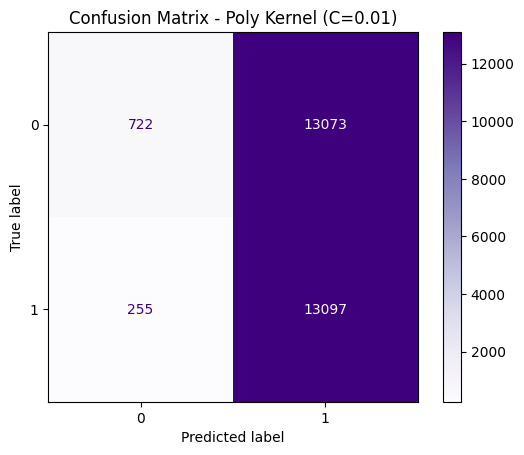

Poly Kernel - C=1
Accuracy: 0.6524846207684091
              precision    recall  f1-score   support

           0       0.72      0.51      0.60     13795
           1       0.61      0.80      0.69     13352

    accuracy                           0.65     27147
   macro avg       0.67      0.65      0.65     27147
weighted avg       0.67      0.65      0.65     27147



<Figure size 600x400 with 0 Axes>

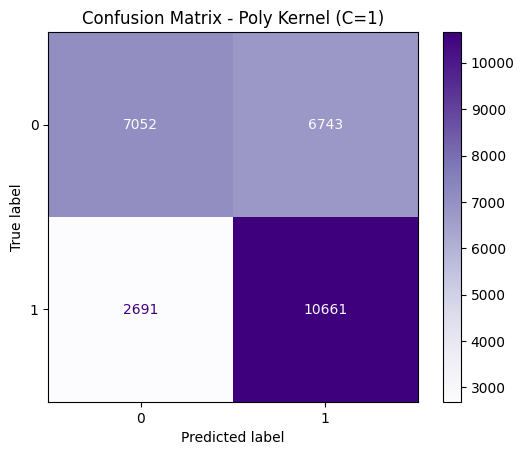

Poly Kernel - C=0.1
Accuracy: 0.5697498802814307
              precision    recall  f1-score   support

           0       0.75      0.23      0.35     13795
           1       0.54      0.92      0.68     13352

    accuracy                           0.57     27147
   macro avg       0.65      0.58      0.51     27147
weighted avg       0.65      0.57      0.51     27147



<Figure size 600x400 with 0 Axes>

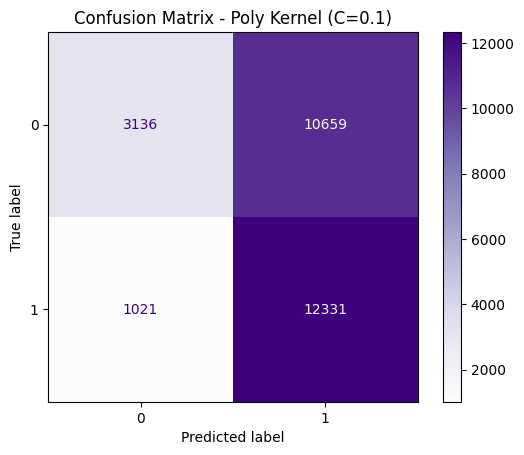

In [5]:
# Poly Kernel with C=0.01
svm_poly_c001 = SVC(kernel='poly', C=0.01)
svm_poly_c001.fit(X_train[:1000], y_train[:1000])
y_pred_poly_c001 = svm_poly_c001.predict(X_test)

print("Poly Kernel - C=0.01")
print("Accuracy:", accuracy_score(y_test, y_pred_poly_c001))
print(classification_report(y_test, y_pred_poly_c001))

cm_poly_c001 = confusion_matrix(y_test, y_pred_poly_c001)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_c001, display_labels=svm_poly_c001.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Poly Kernel (C=0.01)")
plt.grid(False)
plt.show()

# Poly Kernel with C=1
svm_poly_c1 = SVC(kernel='poly', C=1)
svm_poly_c1.fit(X_train[:1000], y_train[:1000])
y_pred_poly_c1 = svm_poly_c1.predict(X_test)

print("Poly Kernel - C=1")
print("Accuracy:", accuracy_score(y_test, y_pred_poly_c1))
print(classification_report(y_test, y_pred_poly_c1))

cm_poly_c1 = confusion_matrix(y_test, y_pred_poly_c1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_c1, display_labels=svm_poly_c1.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Poly Kernel (C=1)")
plt.grid(False)
plt.show()

# Poly Kernel with C=0.1
svm_poly_c01 = SVC(kernel='poly', C=0.1)
svm_poly_c01.fit(X_train[:1000], y_train[:1000])
y_pred_poly_c01 = svm_poly_c01.predict(X_test)

print("Poly Kernel - C=0.1")
print("Accuracy:", accuracy_score(y_test, y_pred_poly_c01))
print(classification_report(y_test, y_pred_poly_c01))

cm_poly_c01 = confusion_matrix(y_test, y_pred_poly_c01)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_c01, display_labels=svm_poly_c01.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Poly Kernel (C=0.1)")
plt.grid(False)
plt.show()


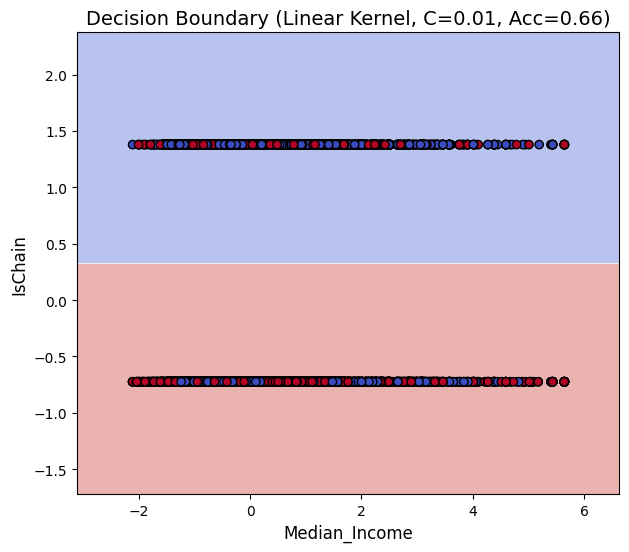

In [7]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
# Selecting 2 features for clear decision boundary
selected_features = ['Median_Income','IsChain']
X_two = df[selected_features]
y = df['RatingBinary']

# Scaling
scaler = StandardScaler()
X_two_scaled = scaler.fit_transform(X_two)

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two_scaled, y, test_size=0.2, random_state=42, stratify=y
)
# Setup: We'll try 3 C values
best_acc_linear = 0
best_c_linear = None
best_model_linear = None

# Trying C = 0.01, 1, 0.1
for C in [0.01, 1, 0.1]:
    model_linear = svm.SVC(kernel='linear', C=C, random_state=42)
    model_linear.fit(X_train2[:1000], y_train2[:1000])
    y_pred_linear = model_linear.predict(X_test2)
    acc_linear = accuracy_score(y_test2, y_pred_linear)

    if acc_linear > best_acc_linear:
        best_acc_linear = acc_linear
        best_c_linear = C
        best_model_linear = model_linear

# Define the decision boundary plotting function
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title, fontsize=14)
    plt.xlabel('Median_Income', fontsize=12)
    plt.ylabel('IsChain', fontsize=12)
    plt.grid(False)
    plt.show()

# Now plot the best decision boundary
plot_decision_boundary(X_test2, y_test2, best_model_linear,
                       f"Decision Boundary (Linear Kernel, C={best_c_linear}, Acc={best_acc_linear:.2f})")


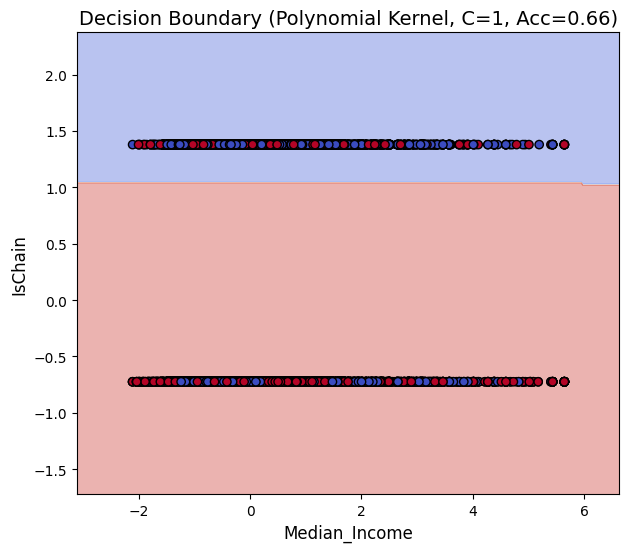

In [10]:
# Trying Polynomial Kernel
best_acc_poly = 0
best_c_poly = None
best_model_poly = None

for C in [0.01, 1, 0.1]:
    model_poly = svm.SVC(kernel='poly', C=C, random_state=42)
    model_poly.fit(X_train2[:1000], y_train2[:1000])
    y_pred_poly = model_poly.predict(X_test2)
    acc_poly = accuracy_score(y_test2, y_pred_poly)

    if acc_poly > best_acc_poly:
        best_acc_poly = acc_poly
        best_c_poly = C
        best_model_poly = model_poly

# Plotting best Polynomial model
plot_decision_boundary(X_test2, y_test2, best_model_poly,
                       f"Decision Boundary (Polynomial Kernel, C={best_c_poly}, Acc={best_acc_poly:.2f})")


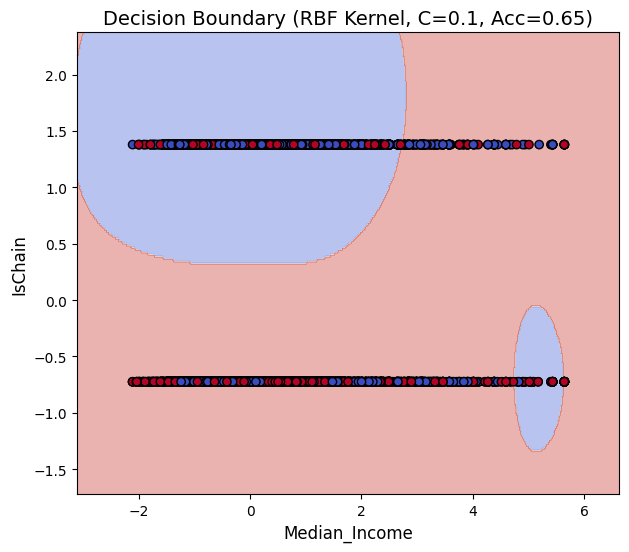

In [9]:
# Trying RBF Kernel
best_acc_rbf = 0
best_c_rbf = None
best_model_rbf = None

for C in [0.01, 1, 0.1]:
    model_rbf = svm.SVC(kernel='rbf', C=C, random_state=42)
    model_rbf.fit(X_train2[:1000], y_train2[:1000])
    y_pred_rbf = model_rbf.predict(X_test2)
    acc_rbf = accuracy_score(y_test2, y_pred_rbf)

    if acc_rbf > best_acc_rbf:
        best_acc_rbf = acc_rbf
        best_c_rbf = C
        best_model_rbf = model_rbf

# Plotting best RBF model
plot_decision_boundary(X_test2, y_test2, best_model_rbf,
                       f"Decision Boundary (RBF Kernel, C={best_c_rbf}, Acc={best_acc_rbf:.2f})")
